In [1]:
# =========================================================
# IMPORTS
# =========================================================
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import joblib

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except Exception:
    XGBOOST_AVAILABLE = False
    print('xgboost is not available. The notebook will use sklearn models only.')

print('Imports loaded successfully.')

Imports loaded successfully.


In [2]:
# =========================================================
# LOAD DATASET
# =========================================================
CSV_PATH = r"C:\Users\Rutik Bhendarkar\Chat Bot 2\Report Analysis\heart_uci.csv"
# If you move the CSV into the same folder as this notebook, use:
# CSV_PATH = 'heart_uci.csv'

df = pd.read_csv(CSV_PATH)
print('Dataset loaded successfully.')
display(df.head())
print('Shape:', df.shape)

Dataset loaded successfully.


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


Shape: (920, 16)


In [3]:
# =========================================================
# BASIC EDA
# =========================================================
print('Columns:')
print(df.columns.tolist())

print('\nInfo:')
print(df.info())

print('\nMissing values:')
print(df.isnull().sum())

print('\nTarget distribution (num):')
print(df['num'].value_counts().sort_index())

Columns:
['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']

Info:
<class 'pandas.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    str    
 3   dataset   920 non-null    str    
 4   cp        920 non-null    str    
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    str    
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    str    
 13  ca        309 non-null    float64
 14  thal      434 non-null    str    
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(2), str(6)
memo

In [4]:
# =========================================================
# TARGET PREPARATION
# num == 0 -> No disease
# num > 0  -> Heart disease present
# =========================================================
df = df.copy()
df['target'] = (df['num'] > 0).astype(int)

# Drop ID and the original multi-class target from features
X = df.drop(columns=['id', 'num', 'target'])
y = df['target']

print('Binary target created.')
print(y.value_counts())

Binary target created.
target
1    509
0    411
Name: count, dtype: int64


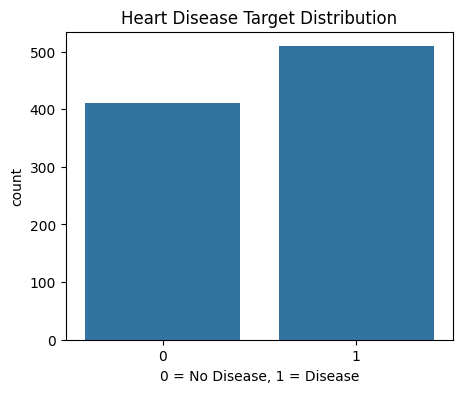

In [5]:
# =========================================================
# SIMPLE VISUALIZATION
# =========================================================
plt.figure(figsize=(5, 4))
sns.countplot(x='target', data=df)
plt.title('Heart Disease Target Distribution')
plt.xlabel('0 = No Disease, 1 = Disease')
plt.show()

In [6]:
# =========================================================
# COLUMN IDENTIFICATION
# =========================================================
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object', 'bool']).columns.tolist()

print('Numeric columns:', numeric_cols)
print('Categorical columns:', categorical_cols)

Numeric columns: ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']
Categorical columns: ['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']


In [7]:
# =========================================================
# PREPROCESSING PIPELINE
# =========================================================
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

print('Preprocessor ready.')

Preprocessor ready.


In [8]:
# =========================================================
# TRAIN TEST SPLIT
# =========================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Train size:', X_train.shape)
print('Test size:', X_test.shape)

Train size: (736, 14)
Test size: (184, 14)


In [9]:
# =========================================================
# MODELS
# =========================================================
models = {}

models['Logistic Regression'] = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=2000))
])

models['Random Forest'] = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight='balanced'
    ))
])

if XGBOOST_AVAILABLE:
    models['XGBoost'] = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', XGBClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=4,
            subsample=0.85,
            colsample_bytree=0.85,
            eval_metric='logloss',
            random_state=42
        ))
    ])

print('Models prepared:', list(models.keys()))

Models prepared: ['Logistic Regression', 'Random Forest', 'XGBoost']


In [10]:
# =========================================================
# TRAIN + EVALUATE MODELS
# =========================================================
results = []

for name, model in models.items():
    print(f'\nTraining {name}...')
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    proba = None
    try:
        proba = model.predict_proba(X_test)[:, 1]
    except Exception:
        pass

    acc = accuracy_score(y_test, preds)
    auc = roc_auc_score(y_test, proba) if proba is not None else np.nan
    results.append({'model': name, 'accuracy': acc, 'auc': auc, 'pipeline': model})
    print('Accuracy:', round(acc, 4))
    if not np.isnan(auc):
        print('ROC-AUC:', round(auc, 4))
    print(classification_report(y_test, preds))

results_df = pd.DataFrame(results).sort_values(by='accuracy', ascending=False)
display(results_df[['model', 'accuracy', 'auc']])


Training Logistic Regression...
Accuracy: 0.837
ROC-AUC: 0.9204
              precision    recall  f1-score   support

           0       0.85      0.77      0.81        82
           1       0.83      0.89      0.86       102

    accuracy                           0.84       184
   macro avg       0.84      0.83      0.83       184
weighted avg       0.84      0.84      0.84       184


Training Random Forest...
Accuracy: 0.8478
ROC-AUC: 0.9293
              precision    recall  f1-score   support

           0       0.85      0.80      0.82        82
           1       0.85      0.88      0.87       102

    accuracy                           0.85       184
   macro avg       0.85      0.84      0.85       184
weighted avg       0.85      0.85      0.85       184


Training XGBoost...
Accuracy: 0.8587
ROC-AUC: 0.9146
              precision    recall  f1-score   support

           0       0.87      0.80      0.84        82
           1       0.85      0.90      0.88       102

   

,model,accuracy,auc
2,XGBoost,0.858696,0.914634
1,Random Forest,0.847826,0.929340
0,Logistic Regression,0.836957,0.920373


In [11]:
# =========================================================
# SELECT BEST MODEL
# =========================================================
best_row = results_df.iloc[0]
best_model_name = best_row['model']
best_model = best_row['pipeline']

print('Best model:', best_model_name)
print('Best accuracy:', round(best_row['accuracy'], 4))

Best model: XGBoost
Best accuracy: 0.8587


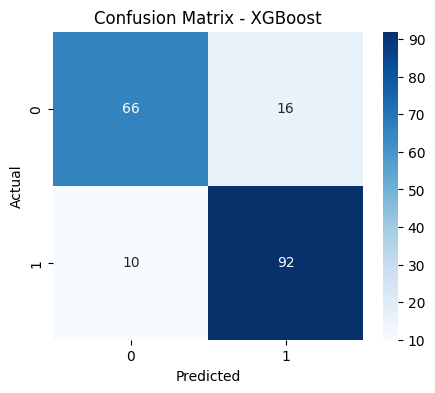

In [12]:
# =========================================================
# CONFUSION MATRIX FOR BEST MODEL
# =========================================================
best_preds = best_model.predict(X_test)
cm = confusion_matrix(y_test, best_preds)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [13]:
# =========================================================
# SAVE ARTIFACTS
# =========================================================
os.makedirs('saved_models', exist_ok=True)

joblib.dump(best_model, 'saved_models/heart_model_pipeline.pkl')
joblib.dump(numeric_cols, 'saved_models/heart_numeric_cols.pkl')
joblib.dump(categorical_cols, 'saved_models/heart_categorical_cols.pkl')
joblib.dump({'best_model_name': best_model_name, 'target_definition': 'num > 0 => heart disease'}, 'saved_models/heart_meta.pkl')

print('Saved to saved_models/')

Saved to saved_models/


## Rule-based heart report analyzer
The next section turns a structured heart report dictionary into a clear summary.

In [14]:
# =========================================================
# RULE-BASED HEART REPORT ENGINE
# =========================================================
def heart_rule_engine(report):
    findings = []
    risk_score = 0

    def add_finding(parameter, severity, message, points):
        nonlocal risk_score
        findings.append({'parameter': parameter, 'severity': severity, 'message': message})
        risk_score += points

    age = report.get('age')
    if age is not None and age >= 60:
        add_finding('Age', 'MODERATE', 'Older age increases heart risk.', 8)

    cp = str(report.get('cp', '')).lower()
    if 'asymptomatic' in cp:
        add_finding('Chest Pain Type', 'HIGH', 'Asymptomatic chest pain pattern can still be risky.', 14)
    elif 'typical angina' in cp:
        add_finding('Chest Pain Type', 'CRITICAL', 'Typical angina is a serious warning sign.', 25)
    elif 'atypical angina' in cp:
        add_finding('Chest Pain Type', 'HIGH', 'Atypical angina may still indicate heart disease.', 18)
    elif 'non-anginal' in cp:
        add_finding('Chest Pain Type', 'LOW', 'Non-anginal chest pain is less concerning, but still monitor symptoms.', 4)

    trestbps = report.get('trestbps')
    if trestbps is not None:
        if trestbps >= 140:
            add_finding('Resting BP', 'HIGH', 'High resting blood pressure detected.', 15)
        elif trestbps <= 90:
            add_finding('Resting BP', 'MODERATE', 'Low resting blood pressure detected.', 6)

    chol = report.get('chol')
    if chol is not None and chol >= 240:
        add_finding('Cholesterol', 'HIGH', 'High cholesterol detected.', 12)

    thalch = report.get('thalch')
    if thalch is not None and thalch < 120:
        add_finding('Max Heart Rate', 'MODERATE', 'Lower maximum heart rate may indicate reduced exercise tolerance.', 8)

    exang = str(report.get('exang', '')).lower()
    if exang == 'true':
        add_finding('Exercise Angina', 'HIGH', 'Exercise-induced angina detected.', 15)

    oldpeak = report.get('oldpeak')
    if oldpeak is not None:
        if oldpeak >= 2.0:
            add_finding('Oldpeak', 'HIGH', 'ST depression level is elevated.', 15)
        elif oldpeak >= 1.0:
            add_finding('Oldpeak', 'MODERATE', 'Mild ST depression detected.', 8)

    ca = report.get('ca')
    if ca is not None and ca >= 2:
        add_finding('Major Vessels', 'HIGH', 'More affected major vessels increase heart risk.', 15)

    thal = str(report.get('thal', '')).lower()
    if 'reversable' in thal:
        add_finding('Thalassemia Test', 'HIGH', 'Reversible defect pattern can be associated with ischemia.', 12)
    elif 'fixed defect' in thal:
        add_finding('Thalassemia Test', 'MODERATE', 'Fixed defect pattern detected.', 8)

    if risk_score >= 55:
        overall_risk = 'CRITICAL'
    elif risk_score >= 35:
        overall_risk = 'HIGH'
    elif risk_score >= 18:
        overall_risk = 'MODERATE'
    else:
        overall_risk = 'LOW'

    if overall_risk == 'CRITICAL':
        summary = 'Serious heart-risk pattern detected. Medical review is strongly recommended.'
    elif overall_risk == 'HIGH':
        summary = 'High heart-risk pattern detected. Please consult a doctor soon.'
    elif overall_risk == 'MODERATE':
        summary = 'Some heart-risk indicators are present. Monitoring is advised.'
    else:
        summary = 'No major heart-risk pattern detected.'

    recommendations = []
    if any(f['parameter'] == 'Resting BP' and f['severity'] in ['HIGH', 'CRITICAL'] for f in findings):
        recommendations.append('Monitor blood pressure and reduce salt intake.')
    if any(f['parameter'] == 'Cholesterol' for f in findings):
        recommendations.append('Maintain a heart-friendly diet and regular exercise.')
    if any(f['parameter'] == 'Exercise Angina' for f in findings):
        recommendations.append('Seek cardiology evaluation if chest discomfort continues.')
    if not recommendations:
        recommendations.append('Continue a healthy lifestyle and regular checkups.')

    return {
        'findings': findings,
        'risk_score': risk_score,
        'overall_risk': overall_risk,
        'summary': summary,
        'recommendations': recommendations
    }

In [15]:
# =========================================================
# HEART SUMMARY GENERATOR
# =========================================================
def generate_heart_summary(result, model_result=None):
    lines = []
    lines.append('=========== HEART REPORT SUMMARY ===========')
    lines.append('')
    lines.append(f"Overall Risk Level: {result.get('overall_risk', 'UNKNOWN')}")
    lines.append(result.get('summary', 'No summary available.'))
    lines.append('')
    if model_result is not None:
        prob = model_result.get('probability', None)
        pred = model_result.get('prediction', None)
        lines.append('AI Model Prediction:')
        if pred == 1:
            lines.append('- The model predicts heart disease risk.')
        else:
            lines.append('- The model predicts lower heart disease risk.')
        if prob is not None:
            lines.append(f'- Risk Probability: {prob}%')
        lines.append('')
    lines.append('Abnormal Findings:')
    if result.get('findings'):
        for item in result['findings']:
            lines.append(f"- {item['parameter']} [{item['severity']}] -> {item['message']}")
    else:
        lines.append('- No major abnormal findings detected.')
    lines.append('')
    lines.append('Recommendations:')
    for rec in result.get('recommendations', []):
        lines.append(f'- {rec}')
    lines.append('')
    lines.append('This summary is supportive and not a replacement for medical diagnosis.')
    return '\n'.join(lines)

In [16]:
# =========================================================
# MODEL PREDICTION FROM STRUCTURED REPORT
# =========================================================
def predict_heart_risk(report_dict, model_pipeline=best_model):
    input_df = pd.DataFrame([report_dict])
    prob = float(model_pipeline.predict_proba(input_df)[0, 1] * 100)
    pred = int(prob >= 50)
    return {'prediction': pred, 'probability': round(prob, 2)}

In [17]:
# =========================================================
# EXAMPLE REPORT TEST
# =========================================================
sample_report = {
    'age': 63,
    'sex': 'Male',
    'dataset': 'Cleveland',
    'cp': 'typical angina',
    'trestbps': 145,
    'chol': 233,
    'fbs': True,
    'restecg': 'lv hypertrophy',
    'thalch': 150,
    'exang': False,
    'oldpeak': 2.3,
    'slope': 'downsloping',
    'ca': 0,
    'thal': 'fixed defect'
}

rule_result = heart_rule_engine(sample_report)
model_result = predict_heart_risk(sample_report)
print(generate_heart_summary(rule_result, model_result))

=========== HEART REPORT SUMMARY ===========

Overall Risk Level: CRITICAL
Serious heart-risk pattern detected. Medical review is strongly recommended.

AI Model Prediction:
- The model predicts lower heart disease risk.
- Risk Probability: 19.35%

Abnormal Findings:
- Age [MODERATE] -> Older age increases heart risk.
- Chest Pain Type [CRITICAL] -> Typical angina is a serious warning sign.
- Resting BP [HIGH] -> High resting blood pressure detected.
- Oldpeak [HIGH] -> ST depression level is elevated.
- Thalassemia Test [MODERATE] -> Fixed defect pattern detected.

Recommendations:
- Monitor blood pressure and reduce salt intake.

This summary is supportive and not a replacement for medical diagnosis.
